# Four-wave mixing: the χ(3) waveguide and the Kerr ring, vs textbook scalings

Companion to web-app testbenches **39 “χ(3) four-wave mixing”** and
**40 “Kerr ring four-wave mixing”**. Nothing in either model says
“generate an idler”: the waveguide applies a Kerr phase to the
*instantaneous envelope power*, the ring shares one χ(3) among its
longitudinal modes — and FWM emerges. Launch a pump at $\nu_p$ and a
signal at $\nu_s$, and a new line grows at exactly

$$ \nu_i = 2\nu_p - \nu_s $$

This notebook measures the idler and pins it against the closed forms
(`examples/wg_fwm.py` / `examples/ring_fwm.py` are the pinned deep dives):

* waveguide: $P_i/P_s = (\gamma P_p L_{nl})^2$ — slope 2 in pump power,
  with the absolute prefactor,
* ring: the same physical length converts **thousands of times** more, because every
  participating wave is resonantly enhanced.

All spectra here are the server's OSA extra-plots (peak-normalised dB), so
every comparison is a **line ratio** — normalisation cancels.

In [1]:
import copy

import numpy as np
import matplotlib.pyplot as plt

from photonflux.nb import Session

C0 = 299_792_458.0
s = Session()

## 1. The straight waveguide (testbench 39)

2 cm of `wg_nl` with the absorption channels off ($\beta_{TPA} =
\sigma_{FCA} = 0$) — a pure Kerr segment:

$$ \gamma = \frac{2\pi n_2}{\lambda A_{eff}}, \qquad
   L_{nl} = \frac{1 + e^{-\alpha L}}{2} L, \qquad k = \gamma L_{nl} $$

Pump 50 mW and signal 1 mW, 10 GHz apart. The two tones beat, the Kerr
phase modulates at the beat, and the modulation scatters pump photons into
an idler on the far side of the pump: FWM as emergent physics.

gamma = 215.8 /W/m, k = gamma*L_nl = 3.52 rad/W, beat = 10.00 GHz


idler - signal = -15.22 dB, theory 20·log10(k·P_p) = -15.09 dB


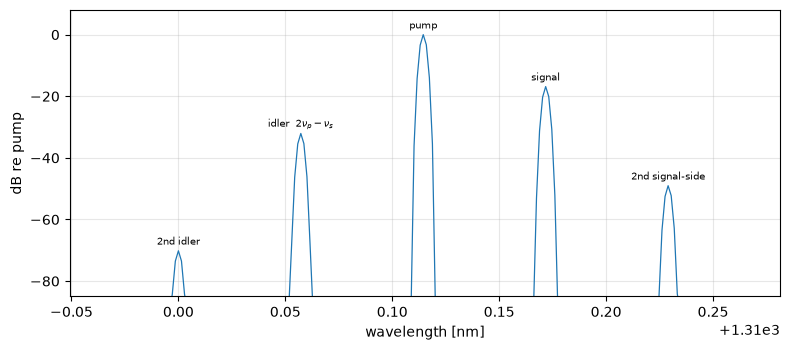

In [2]:
wg_bench = s.load_example("39_chi3_fwm")
wg = wg_bench.instances["WG1"]["settings"]
lam_p = wg_bench["LP.wavelength_nm"] * 1e-9
lam_s = wg_bench["LS.wavelength_nm"] * 1e-9
nu_p, nu_s = C0 / lam_p, C0 / lam_s
beat = nu_p - nu_s                                   # signal is 10 GHz red
a_eff = wg.get("a_eff_um2", 0.1) * 1e-12
gamma = 2 * np.pi * wg["n2_kerr"] / (lam_p * a_eff)
alpha = wg["loss_db_m"] * np.log(10) / 10
L = wg["length_m"]
k_wg = gamma * (1 + np.exp(-alpha * L)) / 2 * L
print(f"gamma = {gamma:.1f} /W/m, k = gamma*L_nl = {k_wg:.2f} rad/W, "
      f"beat = {beat / 1e9:.2f} GHz")


def line_db(wl, db, nu0, m, spacing):
    """Line at nu0 + m*spacing: max dB in a quarter-spacing window."""
    lam_m = C0 / (nu0 + m * spacing) * 1e9
    win = abs(spacing) / 4 * (lam_m * 1e-9) ** 2 / C0 * 1e9
    sel = np.abs(wl - lam_m) < win
    return float(db[sel].max()) if sel.any() else -np.inf


wg_res = s.run(schematic=wg_bench)                   # stored 4 ns transient
wl, db = wg_res.spectrum("p_out")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(wl, db, lw=.9)
for m, lbl in [(0, "pump"), (-1, "signal"), (1, "idler  $2\\nu_p-\\nu_s$"),
               (2, "2nd idler"), (-2, "2nd signal-side")]:
    lam_m = C0 / (nu_p + m * beat) * 1e9
    ax.annotate(lbl, (lam_m, line_db(wl, db, nu_p, m, beat) + 2),
                fontsize=7, ha="center")
ax.set_ylim(-85, 8), ax.grid(alpha=.3)
ax.set_xlabel("wavelength [nm]"), ax.set_ylabel("dB re pump")
fig.tight_layout()

idler_rel = line_db(wl, db, nu_p, 1, beat) - line_db(wl, db, nu_p, -1, beat)
pred = 20 * np.log10(k_wg * wg_bench["LP.power"])
print(f"idler - signal = {idler_rel:.2f} dB, theory 20·log10(k·P_p) = {pred:.2f} dB")
assert abs(idler_rel - pred) < 1.0

The idler sits at $2\nu_p-\nu_s$ **blue of the pump**, mirroring the
signal — and already visible are the next Jacobi–Anger orders (the
two-tone Kerr response is an exact Bessel line spectrum; `wg_fwm.py`
pins all of them). The first-order ratio is the textbook phase-matched
conversion $P_i/P_s = (k P_p)^2$.

### Pump-power slope

$P_i \propto P_p^2$ — 20 dB per pump decade, with the absolute prefactor.
One server run per power; the idler/signal ratio cancels the OSA
normalisation.

[-0.01 -0.03 -0.13 -0.5 ] dB deviation per point


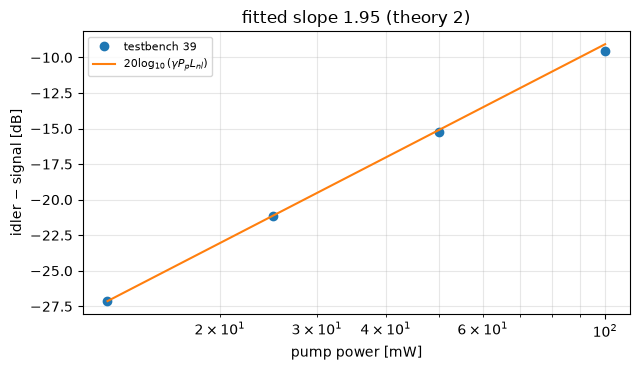

In [3]:
pp_sweep = np.array([12.5e-3, 25e-3, 50e-3, 100e-3])
ratio_db = []
for pp in pp_sweep:
    b = copy.deepcopy(wg_bench.doc)
    b["schematic"]["instances"]["LP"]["settings"]["power"] = float(pp)
    r = s.run(wg_bench.analysis, schematic=b)
    wlp, dbp = r.spectrum("p_out")
    ratio_db.append(line_db(wlp, dbp, nu_p, 1, beat)
                    - line_db(wlp, dbp, nu_p, -1, beat))
ratio_db = np.array(ratio_db)
pred_db = 20 * np.log10(k_wg * pp_sweep)
slope = np.polyfit(np.log10(pp_sweep), ratio_db / 10, 1)[0]

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogx(pp_sweep * 1e3, ratio_db, "o", label="testbench 39")
ax.semilogx(pp_sweep * 1e3, pred_db, "-",
            label="$20\\log_{10}(\\gamma P_p L_{nl})$")
ax.set_xlabel("pump power [mW]"), ax.set_ylabel("idler − signal [dB]")
ax.set_title(f"fitted slope {slope:.2f} (theory 2)")
ax.legend(fontsize=8), ax.grid(alpha=.3, which="both")
fig.tight_layout()
print(np.round(ratio_db - pred_db, 2), "dB deviation per point")
assert abs(slope - 2) < 0.1
assert np.max(np.abs(ratio_db - pred_db)) < 1.0

## Observing pump depletion in the waveguide
A natural phenomena when we deal with four wave mixing is pump depletion, where such a large quantity of pump photons are converted over to signal/idler photons that the pump is significantly drained.

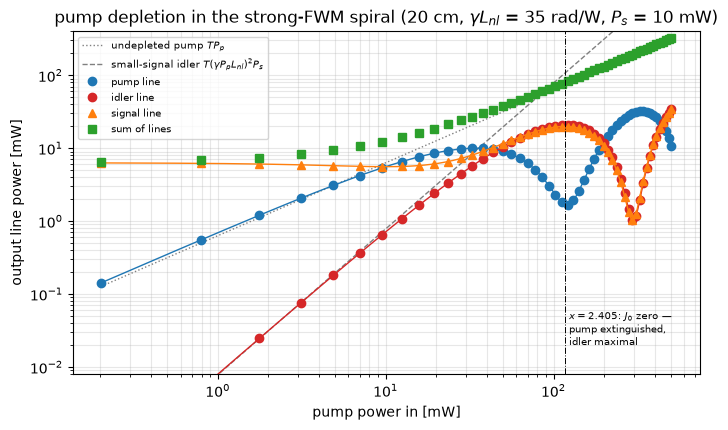

In [18]:
# Pump depletion: 10x the interaction — a 20 cm spiral at 10 dB/m (same
# total dB as the stock 2 cm at 100 dB/m, so T is unchanged) and a 10 mW
# signal. The two-tone Kerr response is an exact Bessel line spectrum in
# x = 2*gamma*L_nl*sqrt(Pp*Ps): at x = 2.405 (the first J0 zero) the pump
# line extinguishes and the idler peaks. The adaptive transient solver
# gives up at this drive strength — fixed-step BDF2 handles it.
from scipy.special import jv

L_S, LOSS_S, PS_S = 0.2, 10.0, 10e-3
alpha_s = LOSS_S * np.log(10) / 10
T_s = np.exp(-alpha_s * L_S)
k_s = gamma * (1 + T_s) / 2 * L_S               # gamma*L_nl = 35 rad/W
x_targets = np.linspace(0.1, 5, 51)
pp_sweep = (x_targets / (2 * k_s)) ** 2 / PS_S  # 1.3 -> 247 mW
STRONG_T = {"mode": "transient", "t_stop": 4e-9, "points": 8000,
            "dtmax": 2e-13, "solver": "bdf2"}

mw = {"pump": [], "signal": [], "idler": [], "sum": []}
for pp in pp_sweep:
    b = copy.deepcopy(wg_bench.doc)
    ins = b["schematic"]["instances"]
    ins["WG1"]["settings"].update(length_m=L_S, loss_db_m=LOSS_S)
    ins["LP"]["settings"]["power"] = float(pp)
    ins["LS"]["settings"]["power"] = PS_S
    r = s.run(STRONG_T, schematic=b)
    wlp, dbp = r.spectrum("p_out")
    rel = {m: line_db(wlp, dbp, nu_p, m, beat) for m in range(-8, 9)}
    scale = float(r["p_out"].mean()) / sum(10 ** (v / 10)
                                           for v in rel.values()
                                           if np.isfinite(v))
    mw["pump"].append(10 ** (rel[0] / 10) * scale)
    mw["signal"].append(10 ** (rel[-1] / 10) * scale)
    mw["idler"].append(10 ** (rel[1] / 10) * scale)
    mw['sum'].append(sum(10 ** (v / 10) * scale for v in rel.values() if np.isfinite(v)))
mw = {k: np.array(v) for k, v in mw.items()}

# exact two-tone (Jacobi-Anger) line powers, valid at any drive level:
# P(pump)   = T (Pp J0^2 + Ps J1^2)
# P(signal) = T (Pp J1^2 + Ps J0^2)     <- pump scatters INTO the signal
# P(idler)  = T (Pp J1^2 + Ps J2^2)
pp_fine = np.geomspace(pp_sweep[0], pp_sweep[-1], 400)
xf = 2 * k_s * np.sqrt(pp_fine * PS_S)
pump_f = T_s * (pp_fine * jv(0, xf) ** 2 + PS_S * jv(1, xf) ** 2) * 1e3
sig_f = T_s * (pp_fine * jv(1, xf) ** 2 + PS_S * jv(0, xf) ** 2) * 1e3
idl_f = T_s * (pp_fine * jv(1, xf) ** 2 + PS_S * jv(2, xf) ** 2) * 1e3
pp_zero = (2.405 / (2 * k_s)) ** 2 / PS_S * 1e3

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.loglog(pp_fine * 1e3, T_s * pp_fine * 1e3, ":", color="gray", lw=1,
          label="undepleted pump $T P_p$")
ax.loglog(pp_fine * 1e3, T_s * (k_s * pp_fine) ** 2 * PS_S * 1e3, "--",
          color="gray", lw=1,
          label="small-signal idler $T(\\gamma P_p L_{nl})^2 P_s$")
ax.loglog(pp_fine * 1e3, pump_f, "-", color="C0", lw=1)
ax.loglog(pp_sweep * 1e3, mw["pump"], "o", color="C0", label="pump line")
ax.loglog(pp_fine * 1e3, idl_f, "-", color="C3", lw=1)
ax.loglog(pp_sweep * 1e3, mw["idler"], "o", color="C3", label="idler line")
ax.loglog(pp_fine * 1e3, sig_f, "-", color="C1", lw=1)
ax.loglog(pp_sweep * 1e3, mw["signal"], "^", color="C1", label="signal line")
ax.loglog(pp_sweep * 1e3, mw["sum"], "s", color="C2", label="sum of lines")

ax.axvline(pp_zero, color="k", lw=.7, ls="-.")
ax.text(pp_zero * 1.06, 0.02, "$x = 2.405$: $J_0$ zero —\n"
        "pump extinguished,\nidler maximal", fontsize=7.5)
ax.set_xlabel("pump power in [mW]"), ax.set_ylabel("output line power [mW]")
ax.set_title("pump depletion in the strong-FWM spiral "
             "(20 cm, $\\gamma L_{nl}$ = 35 rad/W, $P_s$ = 10 mW)")
ax.legend(fontsize=7.5, loc="upper left"), ax.grid(alpha=.3, which="both")
ax.set_ylim(8e-3, 400)
fig.tight_layout()

## 2. FWM inside the ring resonator (testbench 40)

`ring_kerr` is five longitudinal modes (FSR-spaced) sharing the
intracavity Kerr — the modal (Lugiato–Lefever) picture. Pump parked on
resonance, signal one FSR blue: the idler grows in the mode one FSR
**red**, because $2\omega_p = \omega_s + \omega_i$ lands exactly on a ring
resonance — phase matching, ring style. CMT rates from the settings:

$$ \frac{1}{\tau} = \frac{\alpha v_g}{2} + \frac{\kappa_{in}^2}{2T_{rt}}
   + \frac{\kappa_{drop}^2}{2T_{rt}}, \qquad
   g_{eff} = \frac{g_u}{\kappa^2_{c}},\quad
   g_u = \frac{\omega_0}{n_g}\,\frac{n_2 v_g}{V_{eff}} $$

and the small-signal, everything-on-resonance conversion (bus-referred):

$$ \eta = \frac{P_i^{thru}}{P_s^{in}} =
   (g_{eff}\,\tau\,P_p)^2\,(\kappa^2_c\,\tau)^6 $$

In [4]:
ring_bench = s.load_example("40_ring_fwm")
rg = ring_bench.instances["RG1"]["settings"]
lam0 = rg["lambda_res_nm"] * 1e-9
circ = 2 * np.pi * rg["radius_um"] * 1e-6
n_g = rg.get("n_g", 4.0)
v_g = C0 / n_g
t_rt = circ / v_g
fsr = 1 / t_rt
veff = rg.get("a_eff_um2", 0.1) * 1e-12 * circ
inv_i = rg["loss_db_m"] * np.log(10) / 10 * v_g / 2
inv_e1 = rg["kappa2_in"] / (2 * t_rt)
inv_e2 = rg["kappa2_drop"] / (2 * t_rt)
tau_r = 1 / (inv_i + inv_e1 + inv_e2)
k2c = 2 * inv_e1
w0 = 2 * np.pi * C0 / lam0
geff = (w0 / n_g) * rg["n2_kerr"] * v_g / veff / k2c
t_thru2 = (1 - k2c * tau_r) ** 2        # on-resonance thru power transmission


def eta_ring(pp):
    return (geff * tau_r * pp) ** 2 * (k2c * tau_r) ** 6


print(f"FSR = {fsr / 1e9:.3f} GHz | linewidth = {1 / (np.pi * tau_r) / 1e6:.0f} MHz"
      f" | tau = {tau_r * 1e9:.2f} ns | Q = {w0 * tau_r / 2:.2e}")
print(f"thru transmission on resonance = {10 * np.log10(t_thru2):.1f} dB "
      f"(undercoupled)")

nu_p_r = C0 / (ring_bench["LP.wavelength_nm"] * 1e-9)
nu_s_r = C0 / (ring_bench["LS.wavelength_nm"] * 1e-9)
beat_r = nu_s_r - nu_p_r
print(f"signal offset {beat_r / 1e9:+.3f} GHz vs FSR {fsr / 1e9:.3f} GHz")
assert abs(beat_r / fsr - 1) < 0.01, "signal should sit one FSR blue"

FSR = 5.964 GHz | linewidth = 149 MHz | tau = 2.14 ns | Q = 1.54e+06
thru transmission on resonance = -5.1 dB (undercoupled)
signal offset +5.964 GHz vs FSR 5.964 GHz


One subtlety before measuring: with $\tau = 2.1$ ns, the stored 8 ns
transient spends its first half *charging the cavity*. An OSA FFT over the
full record would blur the turn-on into the lines and under-report the
idler by several dB. Probes accept a `spec_start` window bound for exactly
this, so every quantitative run below integrates 16 ns and FFTs only the
settled back half — the schematic-JSON edit is two lines from a notebook.

In [5]:
RING_T = {"mode": "transient", "t_stop": 16e-9, "points": 16000,
          "dtmax": 5e-13}


def ring_doc(pp, ps):
    b = copy.deepcopy(ring_bench.doc)
    ins = b["schematic"]["instances"]
    ins["LP"]["settings"]["power"] = float(pp)
    ins["LS"]["settings"]["power"] = float(ps)
    for pr in b["schematic"]["probes"]:
        if pr["name"] == "p_thru":
            pr["spec_start"] = 8e-9        # OSA window: settled span only
    return b


# first, the linear ring alone: kill the Kerr, pump only, and check the
# on-resonance through transmission against t = 1 - kappa_c^2 tau
lin = ring_doc(1e-3, 0.0)
lin["schematic"]["instances"]["RG1"]["settings"]["n2_kerr"] = 0.0
r0 = s.run(ring_bench.analysis, schematic=lin)
tail = r0.x > 6e-9
t2_meas = r0["p_thru"][tail].mean()                  # mW out of 1 mW in
print(f"on-resonance thru: measured {10 * np.log10(t2_meas):.2f} dB, "
      f"CMT (1-κ_c²τ)² = {10 * np.log10(t_thru2):.2f} dB")
assert abs(t2_meas / t_thru2 - 1) < 0.02

on-resonance thru: measured -5.14 dB, CMT (1-κ_c²τ)² = -5.14 dB


strongest generated line: one FSR red of the pump ✓  (-22.7 dBc vs -22.8 dBc at 2nu_s-nu_p)


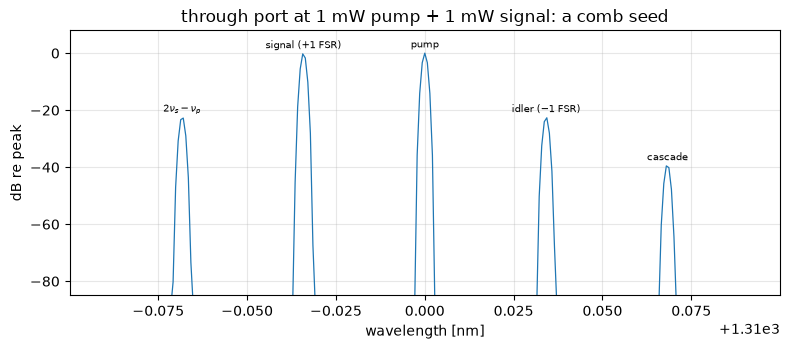

In [6]:
ring_res = s.run(RING_T, schematic=ring_doc(1e-3, 1e-3))   # comb-seed drive
wlr, dbr = ring_res.spectrum("p_thru")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(wlr, dbr, lw=.9)
for m, lbl in [(0, "pump"), (1, "signal (+1 FSR)"), (-1, "idler (−1 FSR)"),
               (2, "$2\\nu_s-\\nu_p$"), (-2, "cascade")]:
    lam_m = C0 / (nu_p_r + m * fsr) * 1e9
    ax.annotate(lbl, (lam_m, line_db(wlr, dbr, nu_p_r, m, fsr) + 2),
                fontsize=7, ha="center")
ax.set_ylim(-85, 8), ax.grid(alpha=.3)
ax.set_xlabel("wavelength [nm]"), ax.set_ylabel("dB re peak")
ax.set_title("through port at 1 mW pump + 1 mW signal: a comb seed")
fig.tight_layout()

# identity: the strongest *generated* line is 2 nu_p - nu_s, one FSR red
gen = {m: line_db(wlr, dbr, nu_p_r, m, fsr) for m in (-2, -1, 2)}
assert max(gen, key=gen.get) == -1, gen
print("strongest generated line: one FSR red of the pump ✓  "
      f"({gen[-1]:.1f} dBc vs {gen[2]:.1f} dBc at 2nu_s-nu_p)")

### Absolute conversion and pump slope

Down at 25–200 µW pump (10 µW signal) the closed form is clean — by 1 mW,
$g_{eff}\tau P_p$ approaches unity and the Kerr shift visibly pulls the
resonances: physics, not error (`ring_fwm.py` quantifies the ramp). The
measured through-port ratio is $\eta / t^2$: the signal leaves the through
port attenuated by the on-resonance transmission $t^2$ (measured above at
−5.1 dB, matching $1-\kappa_c^2\tau$), while the idler is *born*
referenced to the bus.

[-0.01 -0.11 -0.19 -0.31] dB deviation per point


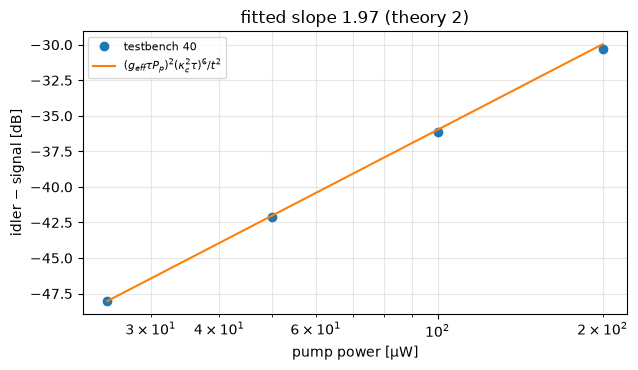

In [7]:
pp_r = np.array([25e-6, 50e-6, 100e-6, 200e-6])
ratio_r = []
for pp in pp_r:
    r = s.run(RING_T, schematic=ring_doc(pp, 10e-6))
    wlx, dbx = r.spectrum("p_thru")
    ratio_r.append(line_db(wlx, dbx, nu_p_r, -1, fsr)
                   - line_db(wlx, dbx, nu_p_r, 1, fsr))
ratio_r = np.array(ratio_r)
pred_r = 10 * np.log10(eta_ring(pp_r) / t_thru2)
slope_r = np.polyfit(np.log10(pp_r), ratio_r / 10, 1)[0]

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogx(pp_r * 1e6, ratio_r, "o", label="testbench 40")
ax.semilogx(pp_r * 1e6, pred_r, "-",
            label="$(g_{eff}\\tau P_p)^2(\\kappa_c^2\\tau)^6 / t^2$")
ax.set_xlabel("pump power [µW]"), ax.set_ylabel("idler − signal [dB]")
ax.set_title(f"fitted slope {slope_r:.2f} (theory 2)")
ax.legend(fontsize=8), ax.grid(alpha=.3, which="both")
fig.tight_layout()
print(np.round(ratio_r - pred_r, 2), "dB deviation per point")
assert abs(slope_r - 2) < 0.15
assert np.max(np.abs(ratio_r - pred_r)) < 1.5

### The point of the ring: resonant enhancement

Same χ(3), same *physical length* — unwrap the ring into 12.6 mm of
straight `wg_nl` (testbench 39's circuit with the length, loss and lasers
edited from the notebook) and measure the same idler/signal ratio at
400 µW pump. The ring should win by
$\eta_{ring} / (t^2\,\eta_{wg}) \sim 10^3$: the resonance enters
**eight times in field** (pump², signal, idler in, and out).

In [8]:
pp_e, ps_e = 400e-6, 40e-6
rr = s.run(RING_T, schematic=ring_doc(pp_e, ps_e))
wl1, db1 = rr.spectrum("p_thru")
ring_ratio = (line_db(wl1, db1, nu_p_r, -1, fsr)
              - line_db(wl1, db1, nu_p_r, 1, fsr))

w = copy.deepcopy(wg_bench.doc)
wgs = w["schematic"]["instances"]
wgs["WG1"]["settings"].update(length_m=circ, loss_db_m=rg["loss_db_m"])
wgs["LP"]["settings"].update(power=pp_e,
                             wavelength_nm=ring_bench["LP.wavelength_nm"])
wgs["LS"]["settings"].update(power=ps_e,
                             wavelength_nm=ring_bench["LS.wavelength_nm"])
ww = s.run(wg_bench.analysis, schematic=w)
wl2, db2 = ww.spectrum("p_out")
wg_ratio = (line_db(wl2, db2, nu_p_r, -1, fsr)
            - line_db(wl2, db2, nu_p_r, 1, fsr))

alpha_r = rg["loss_db_m"] * np.log(10) / 10
lnl_r = (1 + np.exp(-alpha_r * circ)) / 2 * circ
eta_wg = np.exp(-alpha_r * circ) * (gamma * pp_e * lnl_r) ** 2
enh_meas = ring_ratio - wg_ratio
enh_pred = 10 * np.log10(eta_ring(pp_e) / t_thru2 / eta_wg)
print(f"ring idler/signal {ring_ratio:.1f} dB | straight {wg_ratio:.1f} dB")
print(f"enhancement: measured {enh_meas:.1f} dB, predicted {enh_pred:.1f} dB "
      f"(×{10 ** (enh_meas / 10):,.0f})")
assert abs(enh_meas - enh_pred) < 2.5
assert enh_meas > 25, "the ring should win by ~3 orders of magnitude"

ring idler/signal -24.6 dB | straight -59.7 dB
enhancement: measured 35.0 dB, predicted 36.1 dB (×3,183)


---
**Takeaways.** The waveguide idler follows $(\gamma P_p L_{nl})^2$ to a
fraction of a dB — slope 2 in pump, absolute prefactor included. The ring
does the same physics through its modal CMT and converts ~35 dB more in
the same physical length, with the measured value matching
$(g_{eff}\tau P_p)^2 (\kappa_c^2 \tau)^6$.

**Things to try**

* Detune the ring (`RG1.lambda_res_nm` a few hundred fm) and watch the
  conversion collapse as the Lorentzian **to the fourth power** —
  `ring_fwm.py` pins the $|L(\delta)|^8$-in-field law.
* Give the ring dispersion (`d2_hz` ≠ 0): the idler mode walks off the
  equally-spaced grid and conversion dies — phase matching, ring style.
* Crank both lasers to 1 mW in section 2 and count the extra comb lines
  (modes ±2) — the seed of a Kerr frequency comb.